#Importing

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#EDA

In [81]:
data=pd.read_csv("/content/drive/MyDrive/Teen_Mental_Health_Dataset.csv")

In [82]:
data.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [83]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [84]:
data.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [85]:
round(data.isnull().sum()/len(data)*100,2)

,0
age,0.0
gender,0.0
daily_social_media_hours,0.0
platform_usage,0.0
sleep_hours,0.0
screen_time_before_sleep,0.0
academic_performance,0.0
physical_activity,0.0
social_interaction_level,0.0
stress_level,0.0


In [86]:
data['social_interaction_level'].value_counts()


,count
social_interaction_level,
medium,416
low,415
high,369


In [87]:
data['platform_usage'].value_counts()

,count
platform_usage,
Instagram,411
TikTok,398
Both,391


In [88]:
data['depression_label'].value_counts()

,count
depression_label,
0,1169
1,31


#Data Preprocessing

In [89]:
data = pd.get_dummies(
    data,
    columns=['gender', 'social_interaction_level', 'platform_usage'],
    drop_first=True,
    dtype=int
)

In [90]:
data.head()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label,gender_male,social_interaction_level_low,social_interaction_level_medium,platform_usage_Instagram,platform_usage_TikTok
0,14,7.9,7.4,2.9,3.01,1.5,2,2,1,0,1,1,0,1,0
1,19,1.9,8.0,2.9,3.22,0.8,8,1,10,0,0,0,0,0,1
2,17,1.3,7.6,0.5,3.92,0.0,2,4,2,0,0,0,0,1,0
3,15,7.4,6.9,1.6,3.48,0.8,1,7,9,0,1,0,1,0,1
4,15,4.7,4.9,3.0,2.37,1.4,3,5,2,0,0,0,1,0,0


In [91]:
data.drop_duplicates

<bound method DataFrame.drop_duplicates of       age  daily_social_media_hours  sleep_hours  screen_time_before_sleep  \
0      14                       7.9          7.4                       2.9   
1      19                       1.9          8.0                       2.9   
2      17                       1.3          7.6                       0.5   
3      15                       7.4          6.9                       1.6   
4      15                       4.7          4.9                       3.0   
...   ...                       ...          ...                       ...   
1195   18                       6.8          6.6                       2.0   
1196   16                       2.3          8.0                       1.9   
1197   14                       1.7          8.7                       0.7   
1198   15                       3.9          8.5                       2.1   
1199   16                       4.7          6.5                       1.0   

      academic_performance  physical_activity  stress_level  anxiety_level  \
0                     3.01                1.5             2              2   
1                     3.22                0.8             8              1   
2                     3.92                0.0             2              4   
3                     3.48                0.8             1              7   
4                     2.37                1.4             3              5   
...                    ...                ...           ...            ...   
1195                  2.76                1.0             3              4   
1196                  2.12                0.4             7              4   
1197                  3.98                0.8             1              1   
1198                  3.19                0.6             7              9   
1199                  2.91                0.9             5              7   

      addiction_level  depression_label  gender_male  \
0                   1                 0            1   
1                  10                 0            0   
2                   2                 0            0   
3                   9                 0            1   
4                   2                 0            0   
...               ...               ...          ...   
1195                4                 0            0   
1196                4                 0            1   
1197                1                 0            0   
1198                9                 0            1   
1199                3                 0            0   

      social_interaction_level_low  social_interaction_level_medium  \
0                                1                                0   
1                                0                                0   
2                                0                                0   
3                                0                                1   
4                                0                                1   
...                            ...                              ...   
1195                             1                                0   
1196                             0                                0   
1197                             0                                0   
1198                             0                                0   
1199                             0                                1   

      platform_usage_Instagram  platform_usage_TikTok  
0                            1                      0  
1                            0                      1  
2                            1                      0  
3                            0                      1  
4                            0                      0  
...                        ...                    ...  
1195                         1                      0  
1196                         0                      0  
1197                         0                      0

In [92]:
data.shape

(1200, 15)

#Feature Engineering

In [93]:
data['social_vs_sleep'] = (data['daily_social_media_hours'] > data['sleep_hours']).astype(int)

In [94]:
data.head()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label,gender_male,social_interaction_level_low,social_interaction_level_medium,platform_usage_Instagram,platform_usage_TikTok,social_vs_sleep
0,14,7.9,7.4,2.9,3.01,1.5,2,2,1,0,1,1,0,1,0,1
1,19,1.9,8.0,2.9,3.22,0.8,8,1,10,0,0,0,0,0,1,0
2,17,1.3,7.6,0.5,3.92,0.0,2,4,2,0,0,0,0,1,0,0
3,15,7.4,6.9,1.6,3.48,0.8,1,7,9,0,1,0,1,0,1,1
4,15,4.7,4.9,3.0,2.37,1.4,3,5,2,0,0,0,1,0,0,0


#Data Visualization

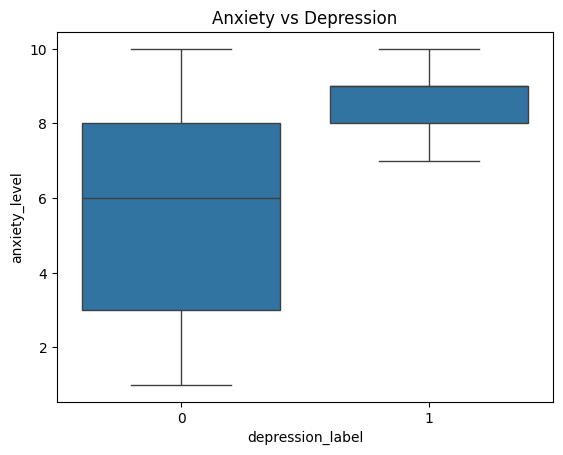

In [95]:
sns.boxplot(x='depression_label', y='anxiety_level', data=data)
plt.title('Anxiety vs Depression')
plt.show()

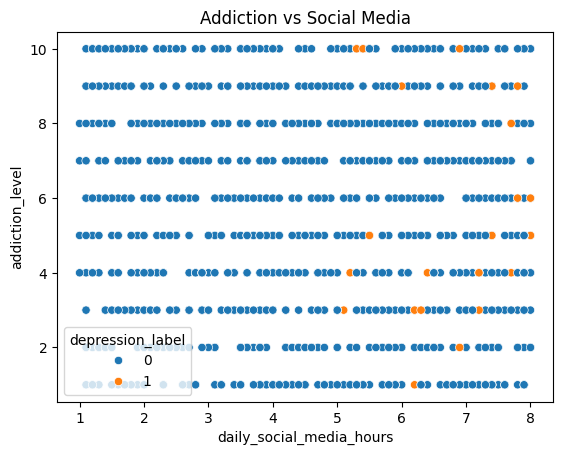

In [96]:
sns.scatterplot(
    x='daily_social_media_hours',
    y='addiction_level',
    hue='depression_label',
    data=data
)
plt.title('Addiction vs Social Media')
plt.show()

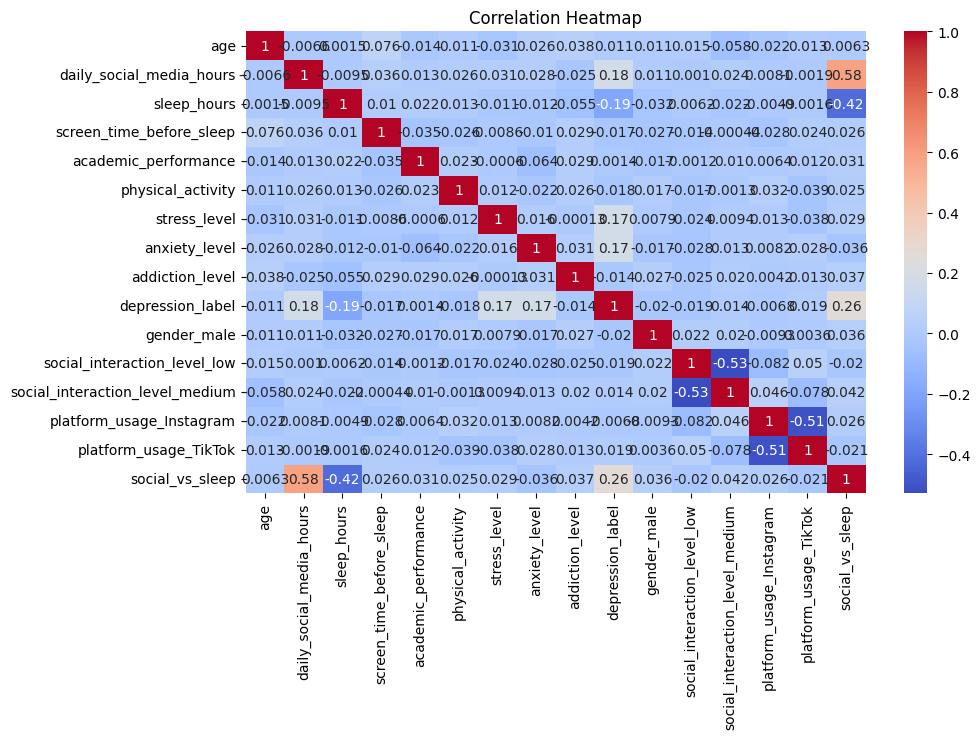

In [97]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

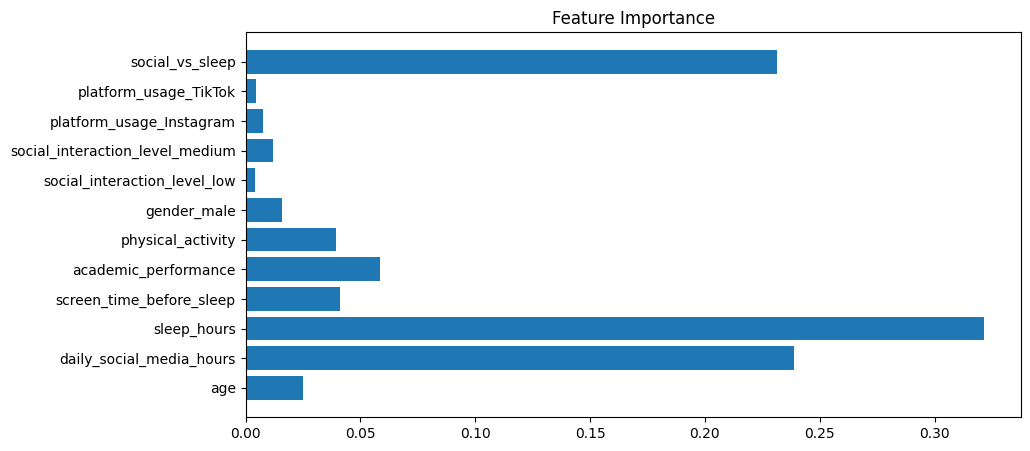

In [100]:
plt.figure(figsize=(10,5))
plt.barh(X.columns, model.feature_importances_)
plt.title("Feature Importance")
plt.show()

#Modeling

In [98]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import SMOTE

X = data.drop([
    'depression_label',
    'stress_level',
    'anxiety_level',
    'addiction_level'
], axis=1)

y = data['depression_label']

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


model = RandomForestClassifier(
    n_estimators=260,
    max_depth=20,
    min_samples_split=15,
    min_samples_leaf=8,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(model.score(X_train, y_train))
print(model.score(X_test, y_test))


0.9541666666666667
0.9208333333333333
